# Tutorial Notebook für die PAP-Toolbox
Willkommen zur PAP-Toolbox! Wahrscheinlich hast du genau so wenig Lust wie ich, mehr Lebenszeit als nötig in das PAP zu stecken. Dieses Skript nimmt dir die nervigste Arbeit im Praktikum ab:
1. Signifikante Stellen zählen und runden (nach den strikten PAP-Regeln).
2. Partielle Ableitungen für die Gauß'sche Fehlerfortpflanzung bilden.
3. Formeln und Datentabellen als sauberen LaTeX-Code exportieren.

**Voraussetzung:** Die Datei `pap_toolbox.py` muss im selben Ordner liegen wie dieses Notebook! Benötigte Libraries: numpy, pandas, sympy, IPython, matplotlib.
Falls diese Libraries noch nicht auf deinem Gerät / virtual Environment sind, lade sie runter. Für Windows über pip:
`pip install numpy pandas sympy IPython matplotlib` bzw `python -m pip install numpy pandas sympy IPython matplotlib`, um die richtige Python Instanz zu verwenden.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pap_toolbox import *

## 1. Runden nach PAP-Regeln
Im PAP gilt: Beginnt der Fehler mit 1 oder 2, nehmen wir 2 signifikante Stellen. Beginnt er mit 3-9, nur eine. Der Messwert wird auf dieselbe Nachkommastelle gerundet. Nullen am Ende dürfen nicht abgeschnitten werden!
Die Funktion `format_latex(wert, fehler)` macht das vollautomatisch:

In [2]:
print("Beispiel 1 (Fehler beginnt mit 4 -> 1 Stelle):")
print(format_latex(val=9.81234, err=0.0456)) 

print("\nBeispiel 2 (Fehler beginnt mit 1 -> 2 Stellen):")
print(format_latex(val=9.81234, err=0.0156))

print("\nBeispiel 3 (Trailing Zeros bleiben erhalten):")
print(format_latex(val=5.2001, err=0.05))

Beispiel 1 (Fehler beginnt mit 4 -> 1 Stelle):
9.81 $\pm$ 0.05

Beispiel 2 (Fehler beginnt mit 1 -> 2 Stellen):
9.812 $\pm$ 0.016

Beispiel 3 (Trailing Zeros bleiben erhalten):
5.20 $\pm$ 0.05


## 2. Statistik von Messreihen
Nehmen wir an, wir haben die Zeit $t$ eines Spielzeugautos mit einer Handstoppuhr 5-mal gemessen. 
Für das Protokoll brauchen wir den Mittelwert und den **Standardfehler des Mittelwerts** als Messfehler.

In [3]:
t_messungen = [4.12, 4.15, 4.09, 4.18, 4.11]

# series_stats berechnet alles auf einmal
stats = series_stats(t_messungen, print_results=True)

# Wir speichern uns den Mittelwert und den Fehler für später
t_val = stats["mean"]
t_err = stats["sem"]

Messreihe (N=5):
  Mittelwert:        4.13
  Std-Abweichung:    0.03535533905932731 (Fehler einer Einzelmessung)
  Std-Fehler (Mittel): 0.015811388300841868 (<= DAS ist dein Messfehler!)


Handzeichnungen & Gewichtetes Mittel

Oft hast du mehrere Messungen derselben Größe mit unterschiedlich großen Fehlern. Das normale arithmetische Mittel ist dann physikalisch falsch. Du brauchst das **fehlergewichtete Mittel**.


In [4]:
# Drei Messungen der Erdbeschleunigung, die erste ist am genauesten
g_werte = [9.81, 9.75, 9.90]
g_fehler = [0.02, 0.08, 0.15] 

g_mean, g_err = weighted_mean(g_werte, g_fehler)
print(f"Gewichtetes Mittel: {format_latex(g_mean, g_err)} m/s^2")

Gewichtetes Mittel: 9.808 $\pm$ 0.019 m/s^2


## 3. Gerätefehler (Digital & Analog)
Die Masse $m$ des Autos wurde auf einer Digitalwaage zu $m = 125.4\,\text{g}$ gemessen. 
Das Datenblatt der Waage sagt: Genauigkeit = $0.5\% + 2 \text{ Digits}$ (bei $0.1\,\text{g}$ Auflösung).

In [5]:
m_val = 125.4
# err_digital(Wert, Prozent, Digits, Auflösung)
m_err = err_digital(m_val, percent=0.5, digits=2, resolution=0.1)

print(f"Masse des Autos: {format_latex(m_val, m_err)} g")

# Die Strecke wurde mit einem Zollstock abgelesen (Ablesefehler: halber Millimeter)
s_val = 2.000 # m
s_err = err_analog(0.001, fraction=0.5) # m

print(f"Gefahrene Strecke: {format_latex(s_val, s_err)} m")

Masse des Autos: 125.4 $\pm$ 0.8 g
Gefahrene Strecke: 2.0000 $\pm$ 0.0005 m


## 4. Symbolische Fehlerfortpflanzung
Wir wollen die kinetische Energie berechnen: $E = \frac{1}{2} m \left(\frac{s}{t}\right)^2$.
Früher musstest du das partiell nach $m, s$ und $t$ ableiten, quadrieren und unter eine Wurzel packen.
Jetzt schreibst du einfach die Formel als String auf!

In [ ]:
# 1. Formel definieren. Nimmt standardmäßig an, dass alle Variablen positiv sind. Kann über all_positive = False geändert werden.
prop_E = ErrorPropagator("0.5 * m * (s / t)**2")

# 2. Zeigt die perfekten LaTeX-Formeln für dein Protokoll an!
prop_E.show_math()

=== THEORETISCHE FORMELN FÜR DAS PROTOKOLL ===


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- Roher LaTeX-Code zum Kopieren ---
Wert:    $$ \frac{m s^{2}}{2 t^{2}} $$
Absolut: $$ \frac{s \sqrt{\Delta m^{2} s^{2} t^{2} + 4 \Delta s^{2} m^{2} t^{2} + 4 \Delta t^{2} m^{2} s^{2}}}{2 t^{3}} $$
Relativ: $$ \frac{\sqrt{\Delta m^{2} s^{2} t^{2} + 4 \Delta s^{2} m^{2} t^{2} + 4 \Delta t^{2} m^{2} s^{2}}}{m s t} $$
-------------------------------------



Jetzt berechnen wir den tatsächlichen Wert von $E$. 
Dazu übergeben wir zwei Dictionaries: Eins mit den Werten, eins mit den Fehlern.

In [7]:
werte_dict = {"m": m_val, "s": s_val, "t": t_val}
fehler_dict = {"m": m_err, "s": s_err, "t": t_err}

# evaluate() berechnet Wert und Fehler in Einem
E_val, E_err = prop_E.evaluate(werte_dict, fehler_dict)

print(f"\nBerechnete Energie: E = {format_latex(E_val, E_err)} J")


Berechnete Energie: E = 14.70 $\pm$ 0.15 J


Das PAP-Skript fordert in Kap. IV.3 explizit: *„Ein Fehlerbeitrag, der kleiner als 20 % des größten Beitrags ist, kann vernachlässigt werden.“*
Die Toolbox kann das automatisch analysieren und die LaTeX-Formel entsprechend einkürzen.
Nehmen wir an, die Strecke $s$ lässt sich extrem genau bestimmen, die Zeit $t$ ist aber ungenau:

In [8]:
daten = {"m": 125.4, "s": 2.0, "t": 4.13}
fehler = {"m": "0.5%", "s": 0.0005, "t": 0.05}

# Analysiert die Beiträge und wirft alles < 20% des stärksten Fehlers raus
prop_E.analyze_error(daten, fehler, threshold=0.20)

=== FEHLER-ANALYSE (Schwelle: 20% vom Maximalbeitrag) ===
Beitrag m       :  20.6% des stärksten Fehlers
Beitrag s       :   2.1% des stärksten Fehlers
Beitrag t       : 100.0% des stärksten Fehlers

=> Gestrichene Terme (< 20%): s

--- Neue, gekürzte LaTeX-Formel fürs Protokoll ---


<IPython.core.display.Math object>

$$ \frac{s^{2} \sqrt{\Delta m^{2} t^{2} + 4 \Delta t^{2} m^{2}}}{2 t^{3}} $$



## 5. Tabellen-Export für das Protokoll
Oft haben wir nicht nur ein Auto, sondern mehrere (oder mehrere Messungen bei Veränderung der Ausgangbedingungen). Wir speichern die Daten in einem Pandas DataFrame.
Das Gute: Wir behalten die rohen Zahlen im DataFrame und formatieren erst im allerletzten Schritt für LaTeX. So kann man mit so vielen Stellen rechnen wie man möchte, und erst am Ende kümmert sich das Skript um das richtige Formatting.

In [9]:
# Wir erstellen ein DataFrame mit 3 Autos
df_autos = pd.DataFrame({
    "Auto": ["Porsche", "Ferrari", "VW Golf"],
    "Masse": [125.4, 110.2, 140.5],
    "Strecke": [2.0, 2.0, 2.0],
    "Zeit": [4.13, 3.85, 5.12]
})

# Wir lassen die Fehlerfortpflanzung über das ganze DataFrame laufen
# (Hinweis: Die Toolbox kann sogar Prozentangaben direkt als String verarbeiten!)
df_autos["Energie"], df_autos["d_Energie"] = prop_E.evaluate(
    vals_dict={"m": df_autos["Masse"], "s": df_autos["Strecke"], "t": df_autos["Zeit"]},
    errs_dict={"m": "0.5%", "s": 0.0005, "t": 0.05} # 0.5% rel. Fehler, s und t absoluter Fehler
)

display(df_autos) # So sieht das rohe, unformatierte DataFrame aus

,Auto,Masse,Strecke,Zeit,Energie,d_Energie
0,Porsche,125.4,2.0,4.13,14.703727,0.363608
1,Ferrari,110.2,2.0,3.85,14.869287,0.393376
2,VW Golf,140.5,2.0,5.12,10.719299,0.216179


Jetzt exportieren wir die Tabelle für LaTeX.
Die `config` Liste definiert, wie die Tabelle aufgebaut wird:
`(Spaltenname, Fehlerspalte_oder_konstanter_Wert, "LaTeX-Header")`
Für reine Textspalten (ohne Fehler) reicht ein 2er-Tupel!

In [10]:
# Hier wurde mit \unit gearbeitet. Bitte schreibt in eurem LaTeX Code keine Einheiten als normalen Text!!
config = [
    ("Auto", "Modell"),                                                 # 2er-Tupel -> Reiner Text
    ("Masse", "0.5%", "$m$ in $\\unit{\\gram}$ "),                      # Konstanter Fehler (sogar als String möglich!)
    ("Zeit", 0.05, "$t$ in $\\unit{\\second}}$"),                       # Konstanter Fehler
    ("Energie", "d_Energie", "$E_{\\text{kin}}$ in $\\unit{\\Joule}$")  # Fehler ist standardmäßig über \pm angegeben, kann aber auch in einer separaten Zeile stehen.
]

latex_tabelle = export_pap_table(
    df=df_autos, 
    config=config, 
    caption="Kinetische Energie der verschiedenen Spielzeugautos.", 
    label="tab:autos"
)

print(latex_tabelle)

\begin{table}[H]
\centering
\caption{Kinetische Energie der verschiedenen Spielzeugautos.}
\label{tab:autos}
\begin{tabular}{cccc}
\toprule
Modell & $m$ in $\unit{\gram}$  & $t$ in $\unit{\second}}$ & $E_{\text{kin}}$ in $\unit{\Joule}$ \\
\midrule
Porsche & 125.4 & 4.13 $\pm$ 0.05 & 14.7 $\pm$ 0.4 \\
Ferrari & 110.2 & 3.85 $\pm$ 0.05 & 14.9 $\pm$ 0.4 \\
VW Golf & 140.5 & 5.12 $\pm$ 0.05 & 10.72 $\pm$ 0.22 \\
\bottomrule
\end{tabular}
\end{table}



## 6. Diskussion schreiben
Angenommen, die theoretische Energie des Porsches hätte $15.0 \pm 0.1$ Joule sein sollen. 
Wie viele Sigma weicht unser Messwert ab? Und was schreibe ich dazu ins Protokoll?

In [11]:
porsche_E = df_autos.loc[0, "Energie"]
porsche_dE = df_autos.loc[0, "d_Energie"]

sigma_abstand = compare_to_literature(
    val=porsche_E, 
    err=porsche_dE, 
    lit_val=15.0, 
    lit_err=0.1, 
    verbose=True
)

--- Vergleich mit Literaturwert ---
Dein Wert:   14.7 $\pm$ 0.4
Literatur:   15.00 $\pm$ 0.10
Abweichung:  0.2963 (absolut)
Sigma-Abst.: 0.79 \sigma

Protokoll-Text:
Der Messwert weicht um 0.79 \sigma vom Literaturwert ab und stimmt im Rahmen der Messgenauigkeit hervorragend überein.


## 9. High-Performance Fitting & Plotting (PAP 2 Ready)
Spätestens in PAP 2 musst (und im PAP 1 willst) du Kurven digital fitten (inkl. $\chi^2$-Auswertung) und Plots für das Protokoll exportieren. 
Die Toolbox bündelt das in nur 2 Zeilen Code. Und um noch mehr Kopfschmerzen zu sparen: Wenn du >1000 Punkte aus dem Oszilloskop hast, rastert die Funktion die Daten automatisch (Vektorschriften + Pixel-Punkte), damit dein LaTeX-Compiler in Overleaf nicht abstürzt :)


In [12]:
# 1. Wir generieren 15.000 fiktive Datenpunkte (z.B. Kondensator-Entladung) mit Rauschen
N = 15000
t_data = np.linspace(0, 10, N)
U_true = 5.0 * np.exp(-t_data / 2.0)
U_noise = U_true + np.random.normal(0, 0.5, N)
dU_error = 0.2 # Konstanter Messfehler des Oszilloskops

# 2. Die theoretische Zielfunktion definieren (x-Variable muss das erste Argument sein!)
def entladung(t, U_0, tau):
    return U_0 * np.exp(-t / tau)

# 3. Der Fit (Gekapselt in einer Zeile!)
# Hinweis: Weil wir y_err_col übergeben, wird automatisch ein GEWICHTETER Fit gemacht!
fit = fit_curve(
    func=entladung, 
    df_or_dict={"t": t_data, "U": U_noise}, 
    x_col="t", 
    y_col="U", 
    y_err_col=dU_error, 
    p0=[5, 2] # Startwerte raten hilft dem Algorithmus, ist aber nicht nötig
)

# Zeigt Parameter, Fehler und reduzierte Chi^2 Güte an!
fit.print_results(param_names=["U_0", r"\tau"])

=== FIT ERGEBNISSE ===
U_0 = 4.992 $\pm$ 0.007
\tau = 2.023 $\pm$ 0.004
Fit-Güte: chi2 = 93121.62, ndof = 14998 -> chi2/ndof = 6.21


Plotten wir das Ergebnis. Die Funktion generiert automatisch eine glatte Fit-Kurve, setzt Fehlerbalken und ein transparentes 1-$\sigma$ Monte-Carlo-Fehlerband.
Da $N > 1000$ Punkte sind, werden die Fehlerbalken intelligent ausgedünnt und der Plot für eine winzige PDF-Dateigröße optimiert.

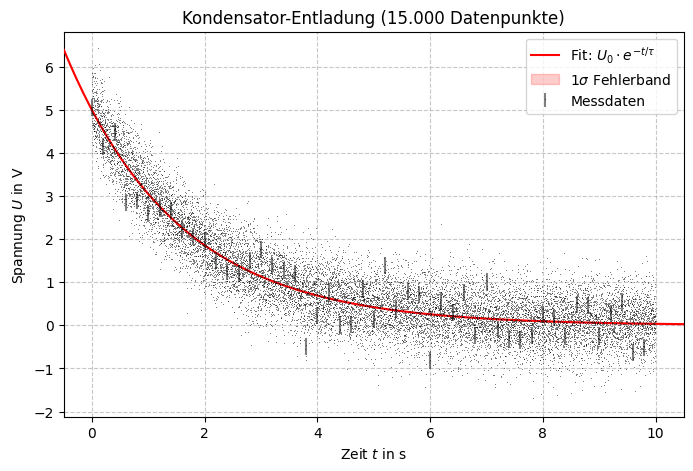

In [13]:
ax = fit.plot(
    title="Kondensator-Entladung (15.000 Datenpunkte)",
    xlabel=r"Zeit $t$ in s",
    ylabel=r"Spannung $U$ in V",
    fit_label=r"Fit: $U_0 \cdot e^{-t/\tau}$"
)

# So würdest du den Plot für LaTeX exportieren (auskommentiert, damit dein Ordner sauber bleibt)
# plt.savefig("entladung_plot.pdf", bbox_inches="tight")
plt.show()